## Exploring the dataset and calculating the metrics (Min, Mean, Std, Max)

In [2]:
import numpy as np
import pandas as pd
import os
from osgeo import gdal
import glob
import matplotlib.pyplot as plt
import geopandas as gpd

In [3]:
path = '/explore/nobackup/people/mfrost2/projects/boreal_chm_dino/training_df_ak_50k_lidar.csv'
data = "4band"

In [4]:
start = path.find("training_") + len("training_")
end = path.find(".csv")
desc = path[start:end]
desc = desc + "_" + data
print(desc) 

df = pd.read_csv(path)
df = df[~df['filename'].isna()]

#Add images fn column
df['image_fn'] = df['filename'].str.replace('labels', 'images')
df = df.rename(columns={'filename': 'label_fn'})

df_ak_50k_lidar_4band


In [5]:
image_fns = df['image_fn']

In [6]:
arr = np.load(image_fns[0])
arr

array([[[ 276.,  281.,  281., ...,  254.,  268.,  263.],
        [ 268.,  276.,  276., ...,  254.,  258.,  263.],
        [ 281.,  293.,  289., ...,  249.,  254.,  263.],
        ...,
        [ 272.,  268.,  272., ...,  268.,  254.,  263.],
        [ 268.,  263.,  268., ...,  258.,  245.,  258.],
        [ 281.,  272.,  254., ...,  268.,  258.,  258.]],

       [[ 418.,  439.,  436., ...,  393.,  408.,  418.],
        [ 422.,  436.,  436., ...,  404.,  408.,  422.],
        [ 439.,  457.,  443., ...,  397.,  418.,  436.],
        ...,
        [ 425.,  464.,  467., ...,  453.,  446.,  450.],
        [ 411.,  439.,  460., ...,  432.,  425.,  481.],
        [ 439.,  422.,  404., ...,  443.,  471.,  460.]],

       [[ 374.,  449.,  523., ...,  457.,  444.,  417.],
        [ 374.,  409.,  431., ...,  435.,  435.,  417.],
        [ 391.,  404.,  413., ...,  360.,  400.,  417.],
        ...,
        [ 487.,  501.,  470., ...,  413.,  378.,  374.],
        [ 483.,  479.,  461., ...,  444.,  39

In [7]:
def compute_per_channel_stats_streaming(df, column_name='image_fn'):
    """
    Memory-efficient version that computes per-channel statistics without loading all data at once.
    """
    
    # Initialize running statistics for each channel
    channel_stats = {}
    for ch in range(4):
        channel_stats[ch] = {
            'n_points': 0,
            'running_sum': 0.0,
            'running_sum_sq': 0.0,
            'min_val': float('inf'),
            'max_val': float('-inf')
        }
    
    n_files = 0
    failed_files = []
    
    #print(f"Processing {len(df)} files (streaming mode)...")
    
    for idx, file_path in enumerate(df[column_name]):
        try:
            data = np.load(file_path)  # Expected shape: (4, 64, 64)
            
            if data.shape != (4, 64, 64):
                print(f"Warning: File {file_path} has shape {data.shape}, expected (4, 64, 64)")
                continue
            
            n_files += 1
            
            # Update statistics for each channel
            for ch in range(4):
                channel_data = data[ch].flatten()
                stats = channel_stats[ch]
                
                stats['n_points'] += len(channel_data)
                stats['running_sum'] += np.sum(channel_data)
                stats['running_sum_sq'] += np.sum(channel_data ** 2)
                stats['min_val'] = min(stats['min_val'], np.min(channel_data))
                stats['max_val'] = max(stats['max_val'], np.max(channel_data))
            
            # if (idx + 1) % 1000 == 0:
            #     print(f"Processed {idx + 1}/{len(df)} files")
                
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
            failed_files.append(file_path)
    
    # Compute final statistics for each channel
    final_stats = {}
    for ch in range(4):
        stats = channel_stats[ch]
        if stats['n_points'] > 0:
            mean = stats['running_sum'] / stats['n_points']
            variance = (stats['running_sum_sq'] / stats['n_points']) - (mean ** 2)
            std = np.sqrt(max(0, variance))  # Ensure non-negative for numerical stability
            
            final_stats[f'channel_{ch}'] = {
                'max': float(stats['max_val']),
                'min': float(stats['min_val']),
                'mean': float(mean),
                'std': float(std),
                'data_points': stats['n_points']
            }
        else:
            final_stats[f'channel_{ch}'] = None
    
    final_stats['summary'] = {
        'total_files_processed': n_files,
        'failed_files': len(failed_files)
    }
    
    return final_stats

# Usage for streaming version
channel_stats_streaming = compute_per_channel_stats_streaming(df, 'image_fn')

In [8]:
def create_stats_dataframe(channel_stats):
    """
    Convert channel statistics to a pandas DataFrame for easier viewing.
    """
    
    data = []
    for ch in range(4):
        channel_key = f'channel_{ch}'
        if channel_stats[channel_key] is not None:
            stats = channel_stats[channel_key]
            data.append({
                'Channel': ch,
                'Max': stats['max'],
                'Min': stats['min'],
                'Mean': stats['mean'],
                'Std Dev': stats['std'],
                'Data Points': stats['data_points']
            })
    
    return pd.DataFrame(data)

# Create and display the summary table
stats_df = create_stats_dataframe(channel_stats_streaming)
print("\nStatistics Summary Table:")
print(stats_df.to_string(index=False, float_format='%.1f'))


Statistics Summary Table:
 Channel     Max    Min   Mean  Std Dev  Data Points
       0  7811.0 -770.0  316.9    126.7    194318336
       1  8373.0 -461.0  490.7    174.2    194318336
       2 10506.0 -451.0  402.6    221.5    194318336
       3 11281.0 -230.0 2266.4    895.6    194318336


In [9]:
#csv_list = glob.glob("./*both*.csv")
csv_list = ['./training_all_ak_100k_both.csv',
 #'./training_df_all_AK_both.csv',
 './training_all_ak_10k_both.csv',
 './training_all_ak_50k_both.csv',
 './training_df_all_AK_filtered_both.csv',
 './training_all_ak_filtered_10k_both.csv',
 './training_all_ak_filtered_50k_both.csv']

Processing 47441 files for per-channel statistics...
Computing statistics for channel 0...
Computing statistics for channel 1...
Computing statistics for channel 2...
Computing statistics for channel 3...
Creating histograms...


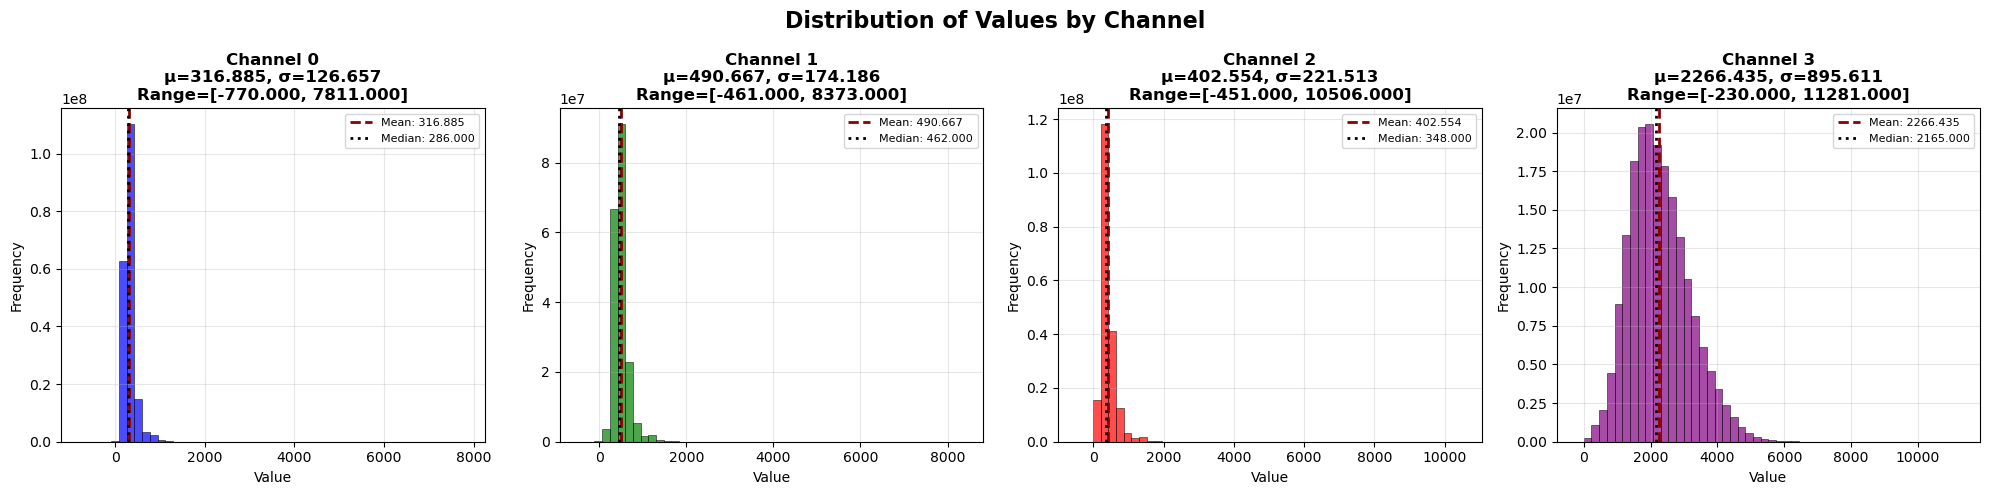


STATISTICS BY CHANNEL
 Channel         Min          Max        Mean    Std Dev Data Points
       0 -770.000000  7811.000000  316.884521 126.657097 194,318,336
       1 -461.000000  8373.000000  490.667236 174.185791 194,318,336
       2 -451.000000 10506.000000  402.553528 221.513092 194,318,336
       3 -230.000000 11281.000000 2266.434570 895.610901 194,318,336

Summary:
  Files processed: 47441
  Failed files: 0


In [10]:
def compute_per_channel_stats_with_histograms(df, column_name='image_fn', bins=50, figsize=(20, 5)):
    """
    Compute max, min, mean, and std dev for each of the 4 channels separately
    and create histograms displayed in a row.
    
    Parameters:
    df: pandas DataFrame containing file paths
    column_name: name of the column containing .npy file paths
    bins: number of bins for histograms
    figsize: figure size for the histogram plot
    
    Returns:
    dict: statistics for each channel
    """
    
    # Initialize lists to collect data for each channel
    channel_data = [[] for _ in range(4)]
    failed_files = []
    
    print(f"Processing {len(df)} files for per-channel statistics...")
    
    for idx, file_path in enumerate(df[column_name]):
        try:
            # Load the .npy file
            data = np.load(file_path)  # Expected shape: (4, 64, 64)
            
            # Verify expected shape
            if data.shape != (4, 64, 64):
                print(f"Warning: File {file_path} has shape {data.shape}, expected (4, 64, 64)")
                continue
            
            # Collect flattened data for each channel
            for ch in range(4):
                channel_data[ch].append(data[ch].flatten())
            
            # # Progress indicator
            # if (idx + 1) % 100 == 0:
            #     print(f"Processed {idx + 1}/{len(df)} files")
                
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
            failed_files.append(file_path)
    
    # Check if we have any valid data
    if not any(channel_data):
        raise ValueError("No valid data files were loaded!")
    
    # Compute statistics for each channel
    channel_stats = {}
    combined_channel_data = []
    
    for ch in range(4):
        if channel_data[ch]:
            print(f"Computing statistics for channel {ch}...")
            combined_data = np.concatenate(channel_data[ch])
            combined_channel_data.append(combined_data)
            
            channel_stats[f'channel_{ch}'] = {
                'max': float(np.max(combined_data)),
                'min': float(np.min(combined_data)),
                'mean': float(np.mean(combined_data)),
                'std': float(np.std(combined_data)),
                'data_points': len(combined_data)
            }
        else:
            print(f"Warning: No valid data found for channel {ch}")
            channel_stats[f'channel_{ch}'] = None
            combined_channel_data.append(None)
    
    # Create histograms
    print("Creating histograms...")
    fig, axes = plt.subplots(1, 4, figsize=figsize)
    fig.suptitle('Distribution of Values by Channel', fontsize=16, fontweight='bold')
    
    # Updated colors: blue, green, red, purple
    colors = ['blue', 'green', 'red', 'purple']
    
    for ch in range(4):
        ax = axes[ch]
        
        if combined_channel_data[ch] is not None:
            data = combined_channel_data[ch]
            stats = channel_stats[f'channel_{ch}']
            
            # Create histogram
            n, bins_edges, patches = ax.hist(data, bins=bins, alpha=0.7, 
                                           color=colors[ch], edgecolor='black', linewidth=0.5)
            
            # Add vertical lines for mean and median
            mean_val = stats['mean']
            median_val = np.median(data)
            
            ax.axvline(mean_val, color='darkred', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.3f}')
            ax.axvline(median_val, color='black', linestyle=':', linewidth=2, label=f'Median: {median_val:.3f}')
            
            # Formatting
            ax.set_title(f'Channel {ch}\n'
                        f'μ={stats["mean"]:.3f}, σ={stats["std"]:.3f}\n'
                        f'Range=[{stats["min"]:.3f}, {stats["max"]:.3f}]', 
                        fontweight='bold')
            ax.set_xlabel('Value')
            ax.set_ylabel('Frequency')
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
            
            # Format y-axis to show counts in scientific notation if needed
            ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
            
        else:
            ax.text(0.5, 0.5, f'No data\nfor Channel {ch}', 
                   transform=ax.transAxes, ha='center', va='center',
                   fontsize=12, fontweight='bold')
            ax.set_title(f'Channel {ch}', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Add summary information
    channel_stats['summary'] = {
        'total_files_processed': len(df) - len(failed_files),
        'failed_files': len(failed_files),
        'files_per_channel': len(channel_data[0]) if channel_data[0] else 0
    }
    
    if failed_files:
        print(f"\nWarning: {len(failed_files)} files failed to load:")
        for f in failed_files[:5]:  # Show first 5 failed files
            print(f"  {f}")
        if len(failed_files) > 5:
            print(f"  ... and {len(failed_files) - 5} more")
    
    return channel_stats

def display_stats_table(channel_stats):
    """
    Display statistics in a nice formatted table.
    """
    print("\n" + "="*80)
    print("STATISTICS BY CHANNEL")
    print("="*80)
    
    # Create pandas DataFrame for nice formatting
    data = []
    for ch in range(4):
        channel_key = f'channel_{ch}'
        if channel_stats[channel_key] is not None:
            stats = channel_stats[channel_key]
            data.append({
                'Channel': ch,
                'Min': f"{stats['min']:.6f}",
                'Max': f"{stats['max']:.6f}",
                'Mean': f"{stats['mean']:.6f}",
                'Std Dev': f"{stats['std']:.6f}",
                'Data Points': f"{stats['data_points']:,}"
            })
        else:
            data.append({
                'Channel': ch,
                'Min': 'N/A',
                'Max': 'N/A',
                'Mean': 'N/A',
                'Std Dev': 'N/A',
                'Data Points': 'N/A'
            })
    
    stats_df = pd.DataFrame(data)
    print(stats_df.to_string(index=False))
    
    print(f"\nSummary:")
    print(f"  Files processed: {channel_stats['summary']['total_files_processed']}")
    print(f"  Failed files: {channel_stats['summary']['failed_files']}")

# Usage examples:

# Simple version with just histograms
channel_stats = compute_per_channel_stats_with_histograms(df, 'image_fn', bins=50, figsize=(20, 5))
display_stats_table(channel_stats)

# Enhanced version with histograms and box plots
# channel_stats = create_enhanced_histograms(df, 'image_fn', bins=50)
# display_stats_table(channel_stats)

In [11]:
def scale_channels(array):
    """
    Scale each channel of the input array independently to 0-1 range.
    
    Parameters:
    array: numpy array of shape (channels, height, width)
    
    Returns:
    scaled_array: numpy array of same shape with float32 data type, values 0-1
    """
    # Get original shape
    original_shape = array.shape
    num_channels = original_shape[0]
    
    # Create output array
    scaled_array = np.zeros(original_shape, dtype=np.float32)
    
    # Process each channel independently
    for c in range(num_channels):
        # Get min and max for this channel
        channel_data = array[c, :, :]
        min_val = np.nanmin(channel_data)
        max_val = np.nanmax(channel_data)
            
        # Avoid division by zero
        if max_val > min_val:
            # Scale to 0-1
            scaled_channel = (channel_data - min_val) / (max_val - min_val)
            scaled_channel = np.clip(scaled_channel, None, 1)
            scaled_channel = np.nan_to_num(scaled_channel, nan=0.0)
            scaled_array[c, :, :] = scaled_channel.astype(np.float32)
        else:
            # If min==max, set all values to 0 or 1
            scaled_array[c, :, :] = 1 if min_val > 0 else 0
    
    return scaled_array

def zscore_normalize_channels(array, channel_means, channel_stds):
    """
    Apply z-score normalization to each channel using provided means and stds.
    
    Parameters:
    array: numpy array of shape (channels, height, width)
    channel_means: list/array of means for each channel
    channel_stds: list/array of standard deviations for each channel
    
    Returns:
    normalized_array: z-score normalized array
    """
    normalized_array = np.zeros_like(array, dtype=np.float32)
    
    for c in range(array.shape[0]):
        if channel_stds[c] > 0:
            normalized_array[c, :, :] = (array[c, :, :] - channel_means[c]) / channel_stds[c]
        else:
            # If std is 0, just subtract the mean
            normalized_array[c, :, :] = array[c, :, :] - channel_means[c]
    
    return normalized_array

def compute_per_channel_stats_with_histograms(df, column_name='image_fn', bins=50, figsize=(20, 5), 
                                            scale=False, zscore=False):
    """
    Compute max, min, mean, and std dev for each of the 4 channels separately
    and create histograms displayed in a row.
    
    Parameters:
    df: pandas DataFrame containing file paths
    column_name: name of the column containing .npy file paths
    bins: number of bins for histograms
    figsize: figure size for the histogram plot
    scale: whether to scale the data to 0-1 range first
    zscore: whether to apply z-score normalization after scaling
    
    Returns:
    dict: statistics for each channel and normalization parameters if applicable
    """
    
    # Initialize lists to collect data for each channel
    channel_data = [[] for _ in range(4)]
    failed_files = []
    
    print(f"Processing {len(df)} files for per-channel statistics...")
    if scale and zscore:
        print("Will apply: 1) Scale to 0-1, 2) Compute stats, 3) Apply z-score normalization")
    elif scale:
        print("Will apply: Scale to 0-1")
    elif zscore:
        print("Will apply: Z-score normalization")
    
    for idx, file_path in enumerate(df[column_name]):
        try:
            # Load the .npy file
            data = np.load(file_path)  # Expected shape: (4, 64, 64)
            
            # Verify expected shape
            if data.shape != (4, 64, 64):
                print(f"Warning: File {file_path} has shape {data.shape}, expected (4, 64, 64)")
                continue
            
            # Scale if requested
            if scale:
                data = scale_channels(data)
            
            # Collect flattened data for each channel (before z-score if applicable)
            for ch in range(4):
                channel_data[ch].append(data[ch].flatten())
                
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
            failed_files.append(file_path)
    
    # Check if we have any valid data - Fix for the ValueError
    has_valid_data = any(len(ch_data) > 0 for ch_data in channel_data)
    if not has_valid_data:
        raise ValueError("No valid data files were loaded!")
    
    # Debug: Check how much data we collected
    for ch in range(4):
        print(f"Channel {ch}: collected data from {len(channel_data[ch])} files")
    
    # Compute statistics for each channel (this gives us the stats we need for z-score)
    channel_stats = {}
    combined_channel_data = []
    channel_means = []
    channel_stds = []
    
    for ch in range(4):
        if len(channel_data[ch]) > 0:  # Check if we have data for this channel
            print(f"Computing statistics for channel {ch}...")
            combined_data = np.concatenate(channel_data[ch])
            print(f"  Channel {ch}: {len(combined_data)} total data points")
            
            # Calculate stats
            ch_mean = float(np.mean(combined_data))
            ch_std = float(np.std(combined_data))
            ch_min = float(np.min(combined_data))
            ch_max = float(np.max(combined_data))
            
            channel_means.append(ch_mean)
            channel_stds.append(ch_std)
            
            # Store initial stats (before z-score if applicable)
            channel_stats[f'channel_{ch}'] = {
                'max': ch_max,
                'min': ch_min,
                'mean': ch_mean,
                'std': ch_std,
                'data_points': len(combined_data)
            }
            
            # Debug: Print the stats as we compute them
            print(f"  Channel {ch} stats: min={ch_min:.6f}, max={ch_max:.6f}, mean={ch_mean:.6f}, std={ch_std:.6f}")
            
            combined_channel_data.append(combined_data)
        else:
            print(f"Warning: No valid data found for channel {ch}")
            channel_stats[f'channel_{ch}'] = None
            combined_channel_data.append(None)
            channel_means.append(0.0)
            channel_stds.append(1.0)
    
    # Apply z-score normalization if requested - Fix for the ValueError
    final_data_for_histograms = combined_channel_data.copy()
    zscore_stats = None
    
    # Check if we have any valid combined channel data for z-score
    has_combined_data = any(data is not None for data in combined_channel_data)
    
    if zscore and has_combined_data:
        print("Applying z-score normalization...")
        zscore_data = [[] for _ in range(4)]
        
        # Re-process files with z-score normalization
        for idx, file_path in enumerate(df[column_name]):
            try:
                data = np.load(file_path)
                if data.shape != (4, 64, 64):
                    continue
                
                if scale:
                    data = scale_channels(data)
                
                # Apply z-score normalization
                data = zscore_normalize_channels(data, channel_means, channel_stds)
                
                for ch in range(4):
                    zscore_data[ch].append(data[ch].flatten())
                    
            except Exception as e:
                continue
        
        # Calculate z-score stats
        zscore_stats = {}
        for ch in range(4):
            if len(zscore_data[ch]) > 0:  # Check if we have z-score data for this channel
                print(f"Computing z-score stats for channel {ch}...")
                combined_zscore = np.concatenate(zscore_data[ch])
                final_data_for_histograms[ch] = combined_zscore
                
                zscore_stats[f'channel_{ch}'] = {
                    'max': float(np.max(combined_zscore)),
                    'min': float(np.min(combined_zscore)),
                    'mean': float(np.mean(combined_zscore)),
                    'std': float(np.std(combined_zscore)),
                    'data_points': len(combined_zscore)
                }
                
                # Debug z-score stats
                stats = zscore_stats[f'channel_{ch}']
                print(f"  Z-score Channel {ch}: min={stats['min']:.6f}, max={stats['max']:.6f}, mean={stats['mean']:.6f}, std={stats['std']:.6f}")
            else:
                zscore_stats[f'channel_{ch}'] = None
    
    # Create histograms using final processed data
    print("Creating histograms...")
    fig, axes = plt.subplots(1, 4, figsize=figsize)
    
    title_suffix = ""
    if scale and zscore:
        title_suffix = " (Scaled 0-1 + Z-score Normalized)"
    elif scale:
        title_suffix = " (Scaled 0-1)"
    elif zscore:
        title_suffix = " (Z-score Normalized)"
    
    fig.suptitle(f'Distribution of Values by Channel{title_suffix}', fontsize=16, fontweight='bold')
    
    # Colors: blue, green, red, purple
    colors = ['blue', 'green', 'red', 'purple']
    
    # Use z-score stats for display if available, otherwise use original stats
    display_stats = zscore_stats if zscore_stats else channel_stats
    
    for ch in range(4):
        ax = axes[ch]
        
        if final_data_for_histograms[ch] is not None:
            data = final_data_for_histograms[ch]
            stats = display_stats[f'channel_{ch}']
            
            if stats is not None:  # Make sure we have stats for this channel
                # Create histogram
                n, bins_edges, patches = ax.hist(data, bins=bins, alpha=0.7, 
                                               color=colors[ch], edgecolor='black', linewidth=0.5)
                
                # Add vertical lines for mean and median
                mean_val = stats['mean']
                median_val = np.median(data)
                
                ax.axvline(mean_val, color='darkred', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.3f}')
                ax.axvline(median_val, color='black', linestyle=':', linewidth=2, label=f'Median: {median_val:.3f}')
                
                # Formatting
                ax.set_title(f'Channel {ch}\n'
                            f'μ={stats["mean"]:.3f}, σ={stats["std"]:.3f}\n'
                            f'Range=[{stats["min"]:.3f}, {stats["max"]:.3f}]', 
                            fontweight='bold')
                ax.set_xlabel('Value')
                ax.set_ylabel('Frequency')
                ax.legend(fontsize=8)
                ax.grid(True, alpha=0.3)
                
                # Format y-axis to show counts in scientific notation if needed
                ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
            else:
                ax.text(0.5, 0.5, f'No stats\nfor Channel {ch}', 
                       transform=ax.transAxes, ha='center', va='center',
                       fontsize=12, fontweight='bold')
                ax.set_title(f'Channel {ch}', fontweight='bold')
        else:
            ax.text(0.5, 0.5, f'No data\nfor Channel {ch}', 
                   transform=ax.transAxes, ha='center', va='center',
                   fontsize=12, fontweight='bold')
            ax.set_title(f'Channel {ch}', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Prepare return data
    result = {
        'original_stats': channel_stats,
        'summary': {
            'total_files_processed': len(df) - len(failed_files),
            'failed_files': len(failed_files),
            'files_per_channel': len(channel_data[0]) if len(channel_data[0]) > 0 else 0
        }
    }
    
    if zscore and zscore_stats:
        result['zscore_stats'] = zscore_stats
        result['normalization_params'] = {
            'means': channel_means,
            'stds': channel_stds
        }
    
    if failed_files:
        print(f"\nWarning: {len(failed_files)} files failed to load:")
        for f in failed_files[:5]:  # Show first 5 failed files
            print(f"  {f}")
        if len(failed_files) > 5:
            print(f"  ... and {len(failed_files) - 5} more")
    
    print(f"\nFunction completed. Returning results with {len(result)} keys.")
    return result

def display_stats_table(results):
    """
    Display statistics in a nice formatted table.
    """
    print("\n" + "="*80)
    print("STATISTICS BY CHANNEL")
    print("="*80)
    
    # Show original stats (after scaling if applied, before z-score)
    print("\nOriginal/Scaled Statistics:")
    data = []
    for ch in range(4):
        channel_key = f'channel_{ch}'
        if channel_key in results['original_stats'] and results['original_stats'][channel_key] is not None:
            stats = results['original_stats'][channel_key]
            data.append({
                'Channel': ch,
                'Min': f"{stats['min']:.6f}",
                'Max': f"{stats['max']:.6f}",
                'Mean': f"{stats['mean']:.6f}",
                'Std Dev': f"{stats['std']:.6f}",
                'Data Points': f"{stats['data_points']:,}"
            })
        else:
            data.append({
                'Channel': ch,
                'Min': 'N/A',
                'Max': 'N/A',
                'Mean': 'N/A',
                'Std Dev': 'N/A',
                'Data Points': 'N/A'
            })
    
    stats_df = pd.DataFrame(data)
    print(stats_df.to_string(index=False))
    
    # Show z-score stats if available
    if 'zscore_stats' in results and results['zscore_stats']:
        print("\nZ-Score Normalized Statistics:")
        zscore_data = []
        for ch in range(4):
            channel_key = f'channel_{ch}'
            if channel_key in results['zscore_stats'] and results['zscore_stats'][channel_key] is not None:
                stats = results['zscore_stats'][channel_key]
                zscore_data.append({
                    'Channel': ch,
                    'Min': f"{stats['min']:.6f}",
                    'Max': f"{stats['max']:.6f}",
                    'Mean': f"{stats['mean']:.6f}",
                    'Std Dev': f"{stats['std']:.6f}",
                    'Data Points': f"{stats['data_points']:,}"
                })
            else:
                zscore_data.append({
                    'Channel': ch,
                    'Min': 'N/A',
                    'Max': 'N/A',
                    'Mean': 'N/A',
                    'Std Dev': 'N/A',
                    'Data Points': 'N/A'
                })
        
        if zscore_data:  # Only create DataFrame if we have data
            zscore_df = pd.DataFrame(zscore_data)
            print(zscore_df.to_string(index=False))
        
        # Show normalization parameters
        if 'normalization_params' in results:
            print(f"\nNormalization Parameters (for PyTorch transforms.Normalize):")
            means = results['normalization_params']['means']
            stds = results['normalization_params']['stds']
            print(f"means = {means}")
            print(f"stds = {stds}")
    
    print(f"\nSummary:")
    print(f"  Files processed: {results['summary']['total_files_processed']}")
    print(f"  Failed files: {results['summary']['failed_files']}")

=== Running without scaling ===
Processing 47441 files for per-channel statistics...
Channel 0: collected data from 47441 files
Channel 1: collected data from 47441 files
Channel 2: collected data from 47441 files
Channel 3: collected data from 47441 files
Computing statistics for channel 0...
  Channel 0: 194318336 total data points
  Channel 0 stats: min=-770.000000, max=7811.000000, mean=316.884521, std=126.657097
Computing statistics for channel 1...
  Channel 1: 194318336 total data points
  Channel 1 stats: min=-461.000000, max=8373.000000, mean=490.667236, std=174.185791
Computing statistics for channel 2...
  Channel 2: 194318336 total data points
  Channel 2 stats: min=-451.000000, max=10506.000000, mean=402.553528, std=221.513092
Computing statistics for channel 3...
  Channel 3: 194318336 total data points
  Channel 3 stats: min=-230.000000, max=11281.000000, mean=2266.434570, std=895.610901
Creating histograms...


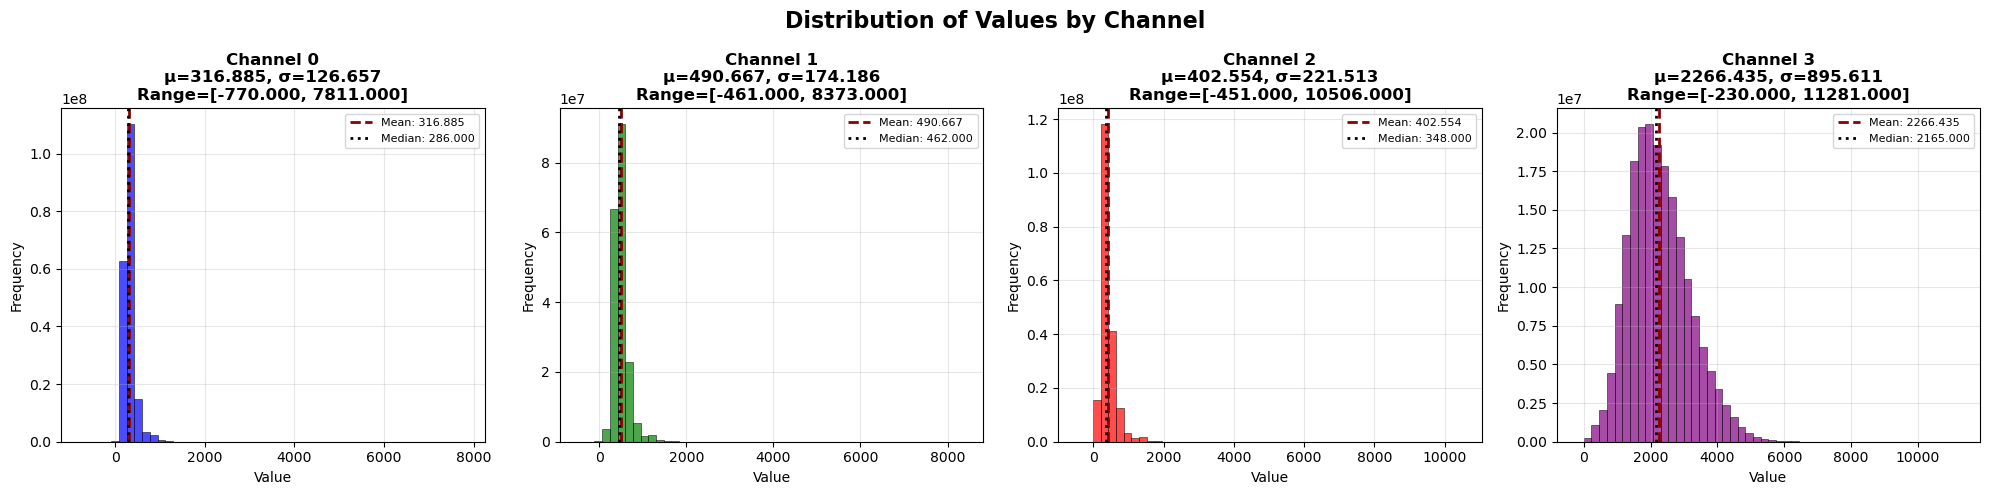


Function completed. Returning results with 2 keys.

STATISTICS BY CHANNEL

Original/Scaled Statistics:
 Channel         Min          Max        Mean    Std Dev Data Points
       0 -770.000000  7811.000000  316.884521 126.657097 194,318,336
       1 -461.000000  8373.000000  490.667236 174.185791 194,318,336
       2 -451.000000 10506.000000  402.553528 221.513092 194,318,336
       3 -230.000000 11281.000000 2266.434570 895.610901 194,318,336

Summary:
  Files processed: 47441
  Failed files: 0


=== Running with scaling ===
Processing 47441 files for per-channel statistics...
Will apply: Scale to 0-1
Channel 0: collected data from 47441 files
Channel 1: collected data from 47441 files
Channel 2: collected data from 47441 files
Channel 3: collected data from 47441 files
Computing statistics for channel 0...
  Channel 0: 194318336 total data points
  Channel 0 stats: min=0.000000, max=1.000000, mean=0.392503, std=0.188047
Computing statistics for channel 1...
  Channel 1: 194318336 to

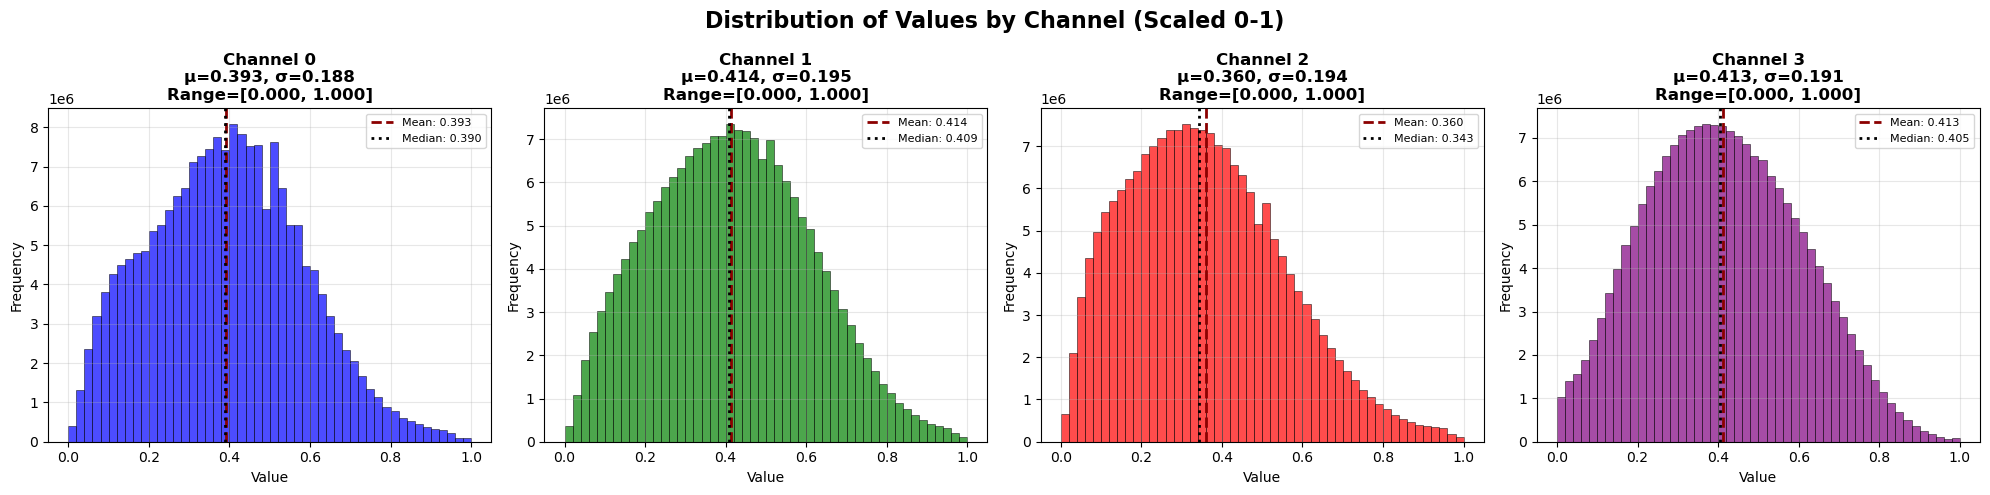


Function completed. Returning results with 2 keys.

STATISTICS BY CHANNEL

Original/Scaled Statistics:
 Channel      Min      Max     Mean  Std Dev Data Points
       0 0.000000 1.000000 0.392503 0.188047 194,318,336
       1 0.000000 1.000000 0.413755 0.194822 194,318,336
       2 0.000000 1.000000 0.359772 0.193822 194,318,336
       3 0.000000 1.000000 0.413116 0.191266 194,318,336

Summary:
  Files processed: 47441
  Failed files: 0


=== Running with scaling and z-score ===
Processing 47441 files for per-channel statistics...
Will apply: 1) Scale to 0-1, 2) Compute stats, 3) Apply z-score normalization
Channel 0: collected data from 47441 files
Channel 1: collected data from 47441 files
Channel 2: collected data from 47441 files
Channel 3: collected data from 47441 files
Computing statistics for channel 0...
  Channel 0: 194318336 total data points
  Channel 0 stats: min=0.000000, max=1.000000, mean=0.392503, std=0.188047
Computing statistics for channel 1...
  Channel 1: 1943183

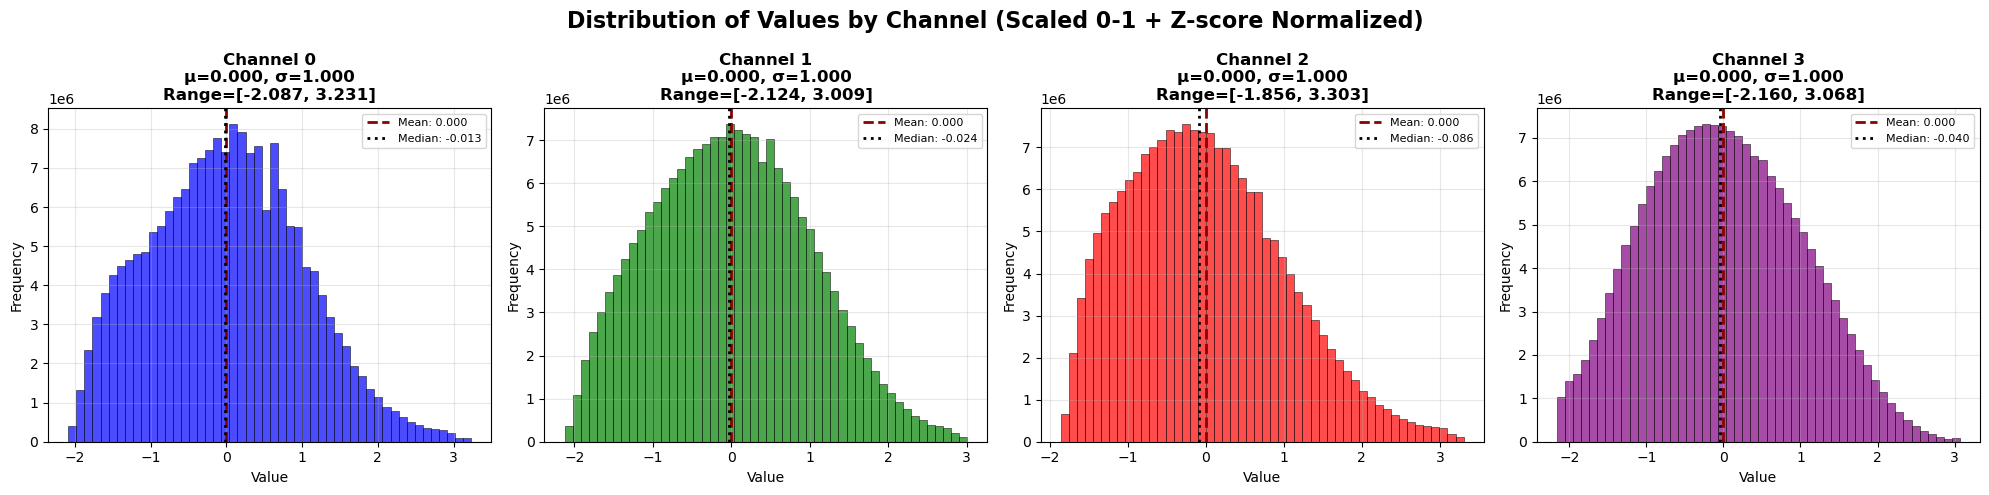


Function completed. Returning results with 4 keys.

STATISTICS BY CHANNEL

Original/Scaled Statistics:
 Channel      Min      Max     Mean  Std Dev Data Points
       0 0.000000 1.000000 0.392503 0.188047 194,318,336
       1 0.000000 1.000000 0.413755 0.194822 194,318,336
       2 0.000000 1.000000 0.359772 0.193822 194,318,336
       3 0.000000 1.000000 0.413116 0.191266 194,318,336

Z-Score Normalized Statistics:
 Channel       Min      Max     Mean  Std Dev Data Points
       0 -2.087255 3.230551 0.000000 1.000000 194,318,336
       1 -2.123757 3.009133 0.000000 1.000000 194,318,336
       2 -1.856197 3.303173 0.000000 1.000000 194,318,336
       3 -2.159903 3.068416 0.000000 1.000000 194,318,336

Normalization Parameters (for PyTorch transforms.Normalize):
means = [0.392503023147583, 0.41375458240509033, 0.3597719669342041, 0.41311609745025635]
stds = [0.18804749846458435, 0.1948220133781433, 0.19382211565971375, 0.19126605987548828]

Summary:
  Files processed: 47441
  Failed fi

In [12]:
# Example 1: Without scaling
print("=== Running without scaling ===")
results = compute_per_channel_stats_with_histograms(df, 'image_fn', bins=50, figsize=(20, 5), scale=False, zscore=False)
display_stats_table(results)

# Example 2: With scaling
print("\n\n=== Running with scaling ===")
results_scaled = compute_per_channel_stats_with_histograms(df, 'image_fn', bins=50, figsize=(20, 5), scale=True, zscore=False)
display_stats_table(results_scaled)

# Example 3: With scaling and z-score
print("\n\n=== Running with scaling and z-score ===")
results_zscore = compute_per_channel_stats_with_histograms(df, 'image_fn', bins=50, figsize=(20, 5), scale=True, zscore=True)
display_stats_table(results_zscore)

In [13]:
for file in csv_list:
    print(file)
   
    df = pd.read_csv(file)
    df = df[~df['filename'].isna()]

    #Add images fn column
    df['image_fn'] = df['filename'].str.replace('labels', 'images')
    df = df.rename(columns={'filename': 'label_fn'})

    # Example 1: Without scaling
    print("=== Running without scaling ===")
    results = compute_per_channel_stats_with_histograms(df, 'image_fn', bins=50, figsize=(20, 5), scale=False, zscore=False)
    # display_stats_table(results)
    
    # # Example 2: With scaling
    # print("\n\n=== Running with scaling ===")
    # results_scaled = compute_per_channel_stats_with_histograms(df, 'image_fn', bins=50, figsize=(20, 5), scale=True, zscore=False)
    # display_stats_table(results_scaled)
    
    # # Example 3: With scaling and z-score
    # print("\n\n=== Running with scaling and z-score ===")
    # results_zscore = compute_per_channel_stats_with_histograms(df, 'image_fn', bins=50, figsize=(20, 5), scale=True, zscore=True)
    # display_stats_table(results_zscore)

./training_all_ak_100k_both.csv


FileNotFoundError: [Errno 2] No such file or directory: './training_all_ak_100k_both.csv'

In [ ]:
tif_list = ['/explore/nobackup/projects/above/misc/ABoVE_Shrubs/srlite/002m/WV02_20200722_M1BS_10300100AB1FD100-sr-02m.tif',
             '/explore/nobackup/projects/above/misc/ABoVE_Shrubs/srlite/002m/WV03_20200704_M1BS_104001005EADB900-sr-02m.tif',
             '/explore/nobackup/projects/above/misc/ABoVE_Shrubs/srlite/002m/WV03_20190822_M1BS_104001005054F700-sr-02m.tif',
             '/explore/nobackup/projects/above/misc/ABoVE_Shrubs/srlite/002m/WV03_20170719_M1BS_104001002F7A2E00-sr-02m.tif',
             '/explore/nobackup/projects/above/misc/ABoVE_Shrubs/srlite/002m/WV02_20160817_M1BS_103001005B484100-sr-02m.tif',
             '/explore/nobackup/projects/above/misc/ABoVE_Shrubs/srlite/002m/WV02_20190820_M1BS_1030010099BF2F00-sr-02m.tif',
             '/explore/nobackup/projects/above/misc/ABoVE_Shrubs/srlite/002m/WV02_20110727_M1BS_103001000D914900-sr-02m.tif',
             '/explore/nobackup/projects/above/misc/ABoVE_Shrubs/srlite/002m/WV02_20190820_M1BS_10300100968FB300-sr-02m.tif',
             '/explore/nobackup/projects/above/misc/ABoVE_Shrubs/srlite/002m/WV02_20190820_M1BS_10300100954DE000-sr-02m.tif',
             '/explore/nobackup/projects/above/misc/ABoVE_Shrubs/srlite/002m/WV02_20120721_M1BS_103001001AB23900-sr-02m.tif']
            # '/explore/nobackup/projects/above/misc/ABoVE_Shrubs/srlite/002m/WV02_20200711_M1BS_10300100A9906900-sr-02m.tif',
            # '/explore/nobackup/projects/above/misc/ABoVE_Shrubs/srlite/002m/WV02_20200711_M1BS_10300100AA76D500-sr-02m.tif']

In [ ]:
ds = gdal.Open(tif_list[0])
arr = ds.ReadAsArray().astype(np.float32)
arr[arr == -9999] = np.nan
arr

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def scale_channels_array(array):
    """
    Scale each channel of the input array independently to 0-1 range.
    
    Parameters:
    array: numpy array of shape (channels, height, width)
    
    Returns:
    scaled_array: numpy array of same shape with float32 data type, values 0-1
    """
    # Get original shape
    original_shape = array.shape
    num_channels = original_shape[0]
    
    # Create output array
    scaled_array = np.zeros(original_shape, dtype=np.float32)
    
    # Process each channel independently
    for c in range(num_channels):
        print(f"Scaling channel {c}...")
        # Get min and max for this channel
        channel_data = array[c, :, :]
        min_val = np.nanmin(channel_data)
        max_val = np.nanmax(channel_data)
        
        print(f"  Channel {c}: min={min_val:.6f}, max={max_val:.6f}")
            
        # Avoid division by zero
        if max_val > min_val:
            # Scale to 0-1
            scaled_channel = (channel_data - min_val) / (max_val - min_val)
            scaled_channel = np.clip(scaled_channel, None, 1)
            scaled_channel = np.nan_to_num(scaled_channel, nan=0.0)
            scaled_array[c, :, :] = scaled_channel.astype(np.float32)
        else:
            # If min==max, set all values to 0 or 1
            scaled_array[c, :, :] = 1 if min_val > 0 else 0
            print(f"  Warning: Channel {c} has constant value, set to {1 if min_val > 0 else 0}")
    
    return scaled_array

def zscore_normalize_channels_array(array, channel_means, channel_stds):
    """
    Apply z-score normalization to each channel using provided means and stds.
    
    Parameters:
    array: numpy array of shape (channels, height, width)
    channel_means: list/array of means for each channel
    channel_stds: list/array of standard deviations for each channel
    
    Returns:
    normalized_array: z-score normalized array
    """
    normalized_array = np.zeros_like(array, dtype=np.float32)
    
    for c in range(array.shape[0]):
        print(f"Z-score normalizing channel {c}...")
        if channel_stds[c] > 0:
            normalized_array[c, :, :] = (array[c, :, :] - channel_means[c]) / channel_stds[c]
        else:
            # If std is 0, just subtract the mean
            normalized_array[c, :, :] = array[c, :, :] - channel_means[c]
            print(f"  Warning: Channel {c} has zero std, only subtracting mean")
    
    return normalized_array

def compute_array_channel_stats_with_histograms(input_array, bins=50, figsize=(20, 5), 
                                               scale=False, zscore=False, use_first_4_channels=True,
                                               sample_size=1000000):
    """
    Compute max, min, mean, and std dev for channels of an array
    and create histograms displayed in a row.
    
    Parameters:
    input_array: numpy array of shape (channels, height, width) - e.g., (8, 7000, 7000)
    bins: number of bins for histograms
    figsize: figure size for the histogram plot
    scale: whether to scale the data to 0-1 range first
    zscore: whether to apply z-score normalization after scaling
    use_first_4_channels: whether to use only the first 4 channels
    sample_size: number of pixels to sample for histogram (to manage memory)
    
    Returns:
    dict: statistics for each channel and normalization parameters if applicable
    """
    
    print(f"Input array shape: {input_array.shape}")
    
    # Select channels to process
    if use_first_4_channels:
        if input_array.shape[0] < 4:
            raise ValueError(f"Array has only {input_array.shape[0]} channels, need at least 4")
        data = input_array[:4, :, :].copy()
        num_channels = 4
        print("Using first 4 channels")
    else:
        data = input_array.copy()
        num_channels = input_array.shape[0]
        print(f"Using all {num_channels} channels")
    
    print(f"Processing shape: {data.shape}")
    total_pixels_per_channel = data.shape[1] * data.shape[2]
    print(f"Total pixels per channel: {total_pixels_per_channel:,}")
    
    if scale and zscore:
        print("Will apply: 1) Scale to 0-1, 2) Compute stats, 3) Apply z-score normalization")
    elif scale:
        print("Will apply: Scale to 0-1")
    elif zscore:
        print("Will apply: Z-score normalization")
    
    # Apply scaling if requested
    if scale:
        print("Applying 0-1 scaling...")
        data = scale_channels_array(data)
    
    # Calculate statistics for each channel
    print("Computing channel statistics...")
    channel_stats = {}
    channel_means = []
    channel_stds = []
    
    for ch in range(num_channels):
        print(f"Processing channel {ch}...")
        channel_data = data[ch, :, :].flatten()
        
        # Remove any NaN or infinite values for statistics
        valid_data = channel_data[np.isfinite(channel_data)]
        
        if len(valid_data) == 0:
            print(f"Warning: Channel {ch} has no valid data")
            channel_stats[f'channel_{ch}'] = None
            channel_means.append(0.0)
            channel_stds.append(1.0)
            continue
        
        # Calculate stats
        ch_mean = float(np.mean(valid_data))
        ch_std = float(np.std(valid_data))
        ch_min = float(np.min(valid_data))
        ch_max = float(np.max(valid_data))
        
        channel_means.append(ch_mean)
        channel_stds.append(ch_std)
        
        channel_stats[f'channel_{ch}'] = {
            'max': ch_max,
            'min': ch_min,
            'mean': ch_mean,
            'std': ch_std,
            'data_points': len(valid_data),
            'total_pixels': len(channel_data),
            'valid_pixels': len(valid_data)
        }
        
        print(f"  Channel {ch}: min={ch_min:.6f}, max={ch_max:.6f}, mean={ch_mean:.6f}, std={ch_std:.6f}")
        print(f"    Valid pixels: {len(valid_data):,}/{len(channel_data):,}")
    
    # Apply z-score normalization if requested
    final_data = data.copy()
    zscore_stats = None
    
    if zscore:
        print("Applying z-score normalization...")
        final_data = zscore_normalize_channels_array(data, channel_means, channel_stds)
        
        # Calculate z-score stats
        zscore_stats = {}
        for ch in range(num_channels):
            if channel_stats[f'channel_{ch}'] is not None:
                print(f"Computing z-score stats for channel {ch}...")
                zscore_data = final_data[ch, :, :].flatten()
                valid_zscore = zscore_data[np.isfinite(zscore_data)]
                
                if len(valid_zscore) > 0:
                    zscore_stats[f'channel_{ch}'] = {
                        'max': float(np.max(valid_zscore)),
                        'min': float(np.min(valid_zscore)),
                        'mean': float(np.mean(valid_zscore)),
                        'std': float(np.std(valid_zscore)),
                        'data_points': len(valid_zscore),
                        'total_pixels': len(zscore_data),
                        'valid_pixels': len(valid_zscore)
                    }
                    
                    stats = zscore_stats[f'channel_{ch}']
                    print(f"  Z-score Channel {ch}: min={stats['min']:.6f}, max={stats['max']:.6f}, mean={stats['mean']:.6f}, std={stats['std']:.6f}")
                else:
                    zscore_stats[f'channel_{ch}'] = None
            else:
                zscore_stats[f'channel_{ch}'] = None
    
    # Create histograms using final processed data
    print("Creating histograms...")
    fig, axes = plt.subplots(1, num_channels, figsize=figsize)
    if num_channels == 1:
        axes = [axes]  # Make it iterable for single channel
    
    title_suffix = ""
    if scale and zscore:
        title_suffix = " (Scaled 0-1 + Z-score Normalized)"
    elif scale:
        title_suffix = " (Scaled 0-1)"
    elif zscore:
        title_suffix = " (Z-score Normalized)"
    
    fig.suptitle(f'Array Channel Distributions{title_suffix}', fontsize=16, fontweight='bold')
    
    # Colors: blue, green, red, purple
    colors = ['blue', 'green', 'red', 'purple']
    
    # Use z-score stats for display if available, otherwise use original stats
    display_stats = zscore_stats if zscore_stats else channel_stats
    
    for ch in range(num_channels):
        ax = axes[ch]
        
        if display_stats[f'channel_{ch}'] is not None:
            # Sample data for histogram (too much data to plot all)
            channel_data = final_data[ch, :, :].flatten()
            valid_data = channel_data[np.isfinite(channel_data)]
            
            # Sample if too much data
            if len(valid_data) > sample_size:
                print(f"Sampling {len(valid_data):,} points to {sample_size:,} for channel {ch} histogram...")
                indices = np.random.choice(len(valid_data), sample_size, replace=False)
                sampled_data = valid_data[indices]
            else:
                sampled_data = valid_data
            
            stats = display_stats[f'channel_{ch}']
            
            # Create histogram
            n, bins_edges, patches = ax.hist(sampled_data, bins=bins, alpha=0.7, 
                                           color=colors[ch], 
                                           edgecolor='black', linewidth=0.5)
            
            # Add vertical lines for mean and median
            mean_val = stats['mean']
            median_val = np.median(sampled_data)
            
            ax.axvline(mean_val, color='darkred', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.3f}')
            ax.axvline(median_val, color='black', linestyle=':', linewidth=2, label=f'Median: {median_val:.3f}')
            
            # Formatting
            ax.set_title(f'Channel {ch}\n'
                        f'μ={stats["mean"]:.3f}, σ={stats["std"]:.3f}\n'
                        f'Range=[{stats["min"]:.3f}, {stats["max"]:.3f}]\n'
                        f'Valid: {stats["valid_pixels"]:,}/{stats["total_pixels"]:,}', 
                        fontweight='bold', fontsize=10)
            ax.set_xlabel('Value')
            ax.set_ylabel('Frequency')
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
            
            # Format y-axis to show counts in scientific notation if needed
            ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
            
        else:
            ax.text(0.5, 0.5, f'No valid data\nfor Channel {ch}', 
                   transform=ax.transAxes, ha='center', va='center',
                   fontsize=12, fontweight='bold')
            ax.set_title(f'Channel {ch}', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Prepare return data
    result = {
        'original_stats': channel_stats,
        'summary': {
            'array_shape': input_array.shape,
            'processed_shape': data.shape,
            'channels_used': num_channels,
            'use_first_4_channels': use_first_4_channels,
            'total_pixels_per_channel': total_pixels_per_channel,
            'sample_size_for_histograms': sample_size
        }
    }
    
    if zscore and zscore_stats:
        result['zscore_stats'] = zscore_stats
        result['normalization_params'] = {
            'means': channel_means,
            'stds': channel_stds
        }
    
    return result

def display_array_stats_table(results):
    """
    Display array statistics in a nice formatted table.
    """
    num_channels = results['summary']['channels_used']
    
    print("\n" + "="*100)
    print("ARRAY STATISTICS BY CHANNEL")
    print("="*100)
    print(f"Original shape: {results['summary']['array_shape']}")
    print(f"Processed shape: {results['summary']['processed_shape']}")
    print(f"Total pixels per channel: {results['summary']['total_pixels_per_channel']:,}")
    
    # Show original stats (after scaling if applied, before z-score)
    print(f"\nOriginal/Scaled Statistics:")
    data = []
    for ch in range(num_channels):
        channel_key = f'channel_{ch}'
        if channel_key in results['original_stats'] and results['original_stats'][channel_key] is not None:
            stats = results['original_stats'][channel_key]
            data.append({
                'Channel': ch,
                'Min': f"{stats['min']:.6f}",
                'Max': f"{stats['max']:.6f}",
                'Mean': f"{stats['mean']:.6f}",
                'Std Dev': f"{stats['std']:.6f}",
                'Valid Pixels': f"{stats['valid_pixels']:,}",
                'Total Pixels': f"{stats['total_pixels']:,}"
            })
        else:
            data.append({
                'Channel': ch,
                'Min': 'N/A',
                'Max': 'N/A',
                'Mean': 'N/A',
                'Std Dev': 'N/A',
                'Valid Pixels': 'N/A',
                'Total Pixels': 'N/A'
            })
    
    import pandas as pd
    stats_df = pd.DataFrame(data)
    print(stats_df.to_string(index=False))
    
    # Show z-score stats if available
    if 'zscore_stats' in results and results['zscore_stats']:
        print(f"\nZ-Score Normalized Statistics:")
        zscore_data = []
        for ch in range(num_channels):
            channel_key = f'channel_{ch}'
            if channel_key in results['zscore_stats'] and results['zscore_stats'][channel_key] is not None:
                stats = results['zscore_stats'][channel_key]
                zscore_data.append({
                    'Channel': ch,
                    'Min': f"{stats['min']:.6f}",
                    'Max': f"{stats['max']:.6f}",
                    'Mean': f"{stats['mean']:.6f}",
                    'Std Dev': f"{stats['std']:.6f}",
                    'Valid Pixels': f"{stats['valid_pixels']:,}"
                })
            else:
                zscore_data.append({
                    'Channel': ch,
                    'Min': 'N/A',
                    'Max': 'N/A',
                    'Mean': 'N/A',
                    'Std Dev': 'N/A',
                    'Valid Pixels': 'N/A'
                })
        
        if zscore_data:  # Only create DataFrame if we have data
            zscore_df = pd.DataFrame(zscore_data)
            print(zscore_df.to_string(index=False))
        
        # Show normalization parameters
        if 'normalization_params' in results:
            print(f"\nNormalization Parameters (for PyTorch transforms.Normalize):")
            means = results['normalization_params']['means']
            stds = results['normalization_params']['stds']
            print(f"means = {means}")
            print(f"stds = {stds}")

# Usage examples:

# Load your array (example)
# your_array = np.load('your_large_array.npy')  # Shape: (8, 7000, 7000)

# 1. Original data, first 4 channels only
results = compute_array_channel_stats_with_histograms(arr, bins=50, figsize=(20, 5), 
                                                     use_first_4_channels=True)

# 2. Scale to 0-1, first 4 channels
# results = compute_array_channel_stats_with_histograms(your_array, bins=50, figsize=(20, 5), 
#                                                      scale=True, use_first_4_channels=True)

# 3. Scale to 0-1 then z-score normalize, first 4 channels (recommended for training)
# results = compute_array_channel_stats_with_histograms(your_array, bins=50, figsize=(20, 5), 
#                                                      scale=True, zscore=True, use_first_4_channels=True)

# 4. Custom sample size for histogram (default is 1M pixels)
# results = compute_array_channel_stats_with_histograms(your_array, bins=50, figsize=(20, 5), 
#                                                      scale=True, zscore=True, use_first_4_channels=True,
#                                                      sample_size=500000)

# display_array_stats_table(results)

# Example usage with actual function call:
print("=== Example: Scale to 0-1 then z-score normalize ===")
# Assuming your array is called 'large_array' with shape (8, 7000, 7000)
# results = compute_array_channel_stats_with_histograms(
#     large_array, 
#     bins=50, 
#     figsize=(20, 5), 
#     scale=True,           # Scale each channel to 0-1
#     zscore=True,          # Then apply z-score normalization
#     use_first_4_channels=True,  # Use only first 4 channels
#     sample_size=1000000   # Sample 1M pixels for histogram
# )
# display_array_stats_table(results)

In [ ]:
### Collect more pixels

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def scale_channels_array(array):
    """
    Scale each channel of the input array independently to 0-1 range.
    
    Parameters:
    array: numpy array of shape (channels, height, width)
    
    Returns:
    scaled_array: numpy array of same shape with float32 data type, values 0-1
    """
    # Get original shape
    original_shape = array.shape
    num_channels = original_shape[0]
    
    # Create output array
    scaled_array = np.zeros(original_shape, dtype=np.float32)
    
    # Process each channel independently
    for c in range(num_channels):
        print(f"Scaling channel {c}...")
        # Get min and max for this channel
        channel_data = array[c, :, :]
        min_val = np.nanmin(channel_data)
        max_val = np.nanmax(channel_data)
        
        print(f"  Channel {c}: min={min_val:.6f}, max={max_val:.6f}")
            
        # Avoid division by zero
        if max_val > min_val:
            # Scale to 0-1
            scaled_channel = (channel_data - min_val) / (max_val - min_val)
            scaled_channel = np.clip(scaled_channel, None, 1)
            scaled_channel = np.nan_to_num(scaled_channel, nan=0.0)
            scaled_array[c, :, :] = scaled_channel.astype(np.float32)
        else:
            # If min==max, set all values to 0 or 1
            scaled_array[c, :, :] = 1 if min_val > 0 else 0
            print(f"  Warning: Channel {c} has constant value, set to {1 if min_val > 0 else 0}")
    
    return scaled_array

def zscore_normalize_channels_array(array, channel_means, channel_stds):
    """
    Apply z-score normalization to each channel using provided means and stds.
    
    Parameters:
    array: numpy array of shape (channels, height, width)
    channel_means: list/array of means for each channel
    channel_stds: list/array of standard deviations for each channel
    
    Returns:
    normalized_array: z-score normalized array
    """
    normalized_array = np.zeros_like(array, dtype=np.float32)
    
    for c in range(array.shape[0]):
        print(f"Z-score normalizing channel {c}...")
        if channel_stds[c] > 0:
            normalized_array[c, :, :] = (array[c, :, :] - channel_means[c]) / channel_stds[c]
        else:
            # If std is 0, just subtract the mean
            normalized_array[c, :, :] = array[c, :, :] - channel_means[c]
            print(f"  Warning: Channel {c} has zero std, only subtracting mean")
    
    return normalized_array

def compute_array_channel_stats_with_histograms(input_array, bins=50, figsize=(20, 5), 
                                               scale=False, zscore=False, use_first_4_channels=True,
                                               sample_size=1000000):
    """
    Compute max, min, mean, and std dev for channels of an array
    and create histograms displayed in a row.
    
    Parameters:
    input_array: numpy array of shape (channels, height, width) - e.g., (8, 7000, 7000)
    bins: number of bins for histograms
    figsize: figure size for the histogram plot
    scale: whether to scale the data to 0-1 range first
    zscore: whether to apply z-score normalization after scaling
    use_first_4_channels: whether to use only the first 4 channels
    sample_size: number of pixels to sample for histogram (to manage memory)
    
    Returns:
    dict: statistics for each channel and normalization parameters if applicable
    """
    
    print(f"Input array shape: {input_array.shape}")
    
    # Select channels to process
    if use_first_4_channels:
        if input_array.shape[0] < 4:
            raise ValueError(f"Array has only {input_array.shape[0]} channels, need at least 4")
        data = input_array[:4, :, :].copy()
        num_channels = 4
        print("Using first 4 channels")
    else:
        data = input_array.copy()
        num_channels = input_array.shape[0]
        print(f"Using all {num_channels} channels")
    
    print(f"Processing shape: {data.shape}")
    total_pixels_per_channel = data.shape[1] * data.shape[2]
    print(f"Total pixels per channel: {total_pixels_per_channel:,}")
    
    if scale and zscore:
        print("Will apply: 1) Scale to 0-1, 2) Compute stats, 3) Apply z-score normalization")
    elif scale:
        print("Will apply: Scale to 0-1")
    elif zscore:
        print("Will apply: Z-score normalization")
    
    # Apply scaling if requested
    if scale:
        print("Applying 0-1 scaling...")
        data = scale_channels_array(data)
    
    # Calculate statistics for each channel
    print("Computing channel statistics...")
    channel_stats = {}
    channel_means = []
    channel_stds = []
    
    for ch in range(num_channels):
        print(f"Processing channel {ch}...")
        channel_data = data[ch, :, :].flatten()
        
        # Remove any NaN or infinite values for statistics
        valid_data = channel_data[np.isfinite(channel_data)]
        
        if len(valid_data) == 0:
            print(f"Warning: Channel {ch} has no valid data")
            channel_stats[f'channel_{ch}'] = None
            channel_means.append(0.0)
            channel_stds.append(1.0)
            continue
        
        # Calculate stats
        ch_mean = float(np.mean(valid_data))
        ch_std = float(np.std(valid_data))
        ch_min = float(np.min(valid_data))
        ch_max = float(np.max(valid_data))
        
        channel_means.append(ch_mean)
        channel_stds.append(ch_std)
        
        channel_stats[f'channel_{ch}'] = {
            'max': ch_max,
            'min': ch_min,
            'mean': ch_mean,
            'std': ch_std,
            'data_points': len(valid_data),
            'total_pixels': len(channel_data),
            'valid_pixels': len(valid_data)
        }
        
        print(f"  Channel {ch}: min={ch_min:.6f}, max={ch_max:.6f}, mean={ch_mean:.6f}, std={ch_std:.6f}")
        print(f"    Valid pixels: {len(valid_data):,}/{len(channel_data):,}")
    
    # Apply z-score normalization if requested
    final_data = data.copy()
    zscore_stats = None
    
    if zscore:
        print("Applying z-score normalization...")
        final_data = zscore_normalize_channels_array(data, channel_means, channel_stds)
        
        # Calculate z-score stats
        zscore_stats = {}
        for ch in range(num_channels):
            if channel_stats[f'channel_{ch}'] is not None:
                print(f"Computing z-score stats for channel {ch}...")
                zscore_data = final_data[ch, :, :].flatten()
                valid_zscore = zscore_data[np.isfinite(zscore_data)]
                
                if len(valid_zscore) > 0:
                    zscore_stats[f'channel_{ch}'] = {
                        'max': float(np.max(valid_zscore)),
                        'min': float(np.min(valid_zscore)),
                        'mean': float(np.mean(valid_zscore)),
                        'std': float(np.std(valid_zscore)),
                        'data_points': len(valid_zscore),
                        'total_pixels': len(zscore_data),
                        'valid_pixels': len(valid_zscore)
                    }
                    
                    stats = zscore_stats[f'channel_{ch}']
                    print(f"  Z-score Channel {ch}: min={stats['min']:.6f}, max={stats['max']:.6f}, mean={stats['mean']:.6f}, std={stats['std']:.6f}")
                else:
                    zscore_stats[f'channel_{ch}'] = None
            else:
                zscore_stats[f'channel_{ch}'] = None
    
    # Create histograms using final processed data
    print("Creating histograms...")
    fig, axes = plt.subplots(1, num_channels, figsize=figsize)
    if num_channels == 1:
        axes = [axes]  # Make it iterable for single channel
    
    title_suffix = ""
    if scale and zscore:
        title_suffix = " (Scaled 0-1 + Z-score Normalized)"
    elif scale:
        title_suffix = " (Scaled 0-1)"
    elif zscore:
        title_suffix = " (Z-score Normalized)"
    
    fig.suptitle(f'Array Channel Distributions{title_suffix}', fontsize=16, fontweight='bold')
    
    # Colors: blue, green, red, purple
    colors = ['blue', 'green', 'red', 'purple']
    
    # Use z-score stats for display if available, otherwise use original stats
    display_stats = zscore_stats if zscore_stats else channel_stats
    
    for ch in range(num_channels):
        ax = axes[ch]
        
        if display_stats[f'channel_{ch}'] is not None:
            # Sample data for histogram (too much data to plot all)
            channel_data = final_data[ch, :, :].flatten()
            valid_data = channel_data[np.isfinite(channel_data)]
            
            # Sample if too much data
            if len(valid_data) > sample_size:
                print(f"Sampling {len(valid_data):,} points to {sample_size:,} for channel {ch} histogram...")
                indices = np.random.choice(len(valid_data), sample_size, replace=False)
                sampled_data = valid_data[indices]
            else:
                sampled_data = valid_data
            
            stats = display_stats[f'channel_{ch}']
            
            # Create histogram
            n, bins_edges, patches = ax.hist(sampled_data, bins=bins, alpha=0.7, 
                                           color=colors[ch], 
                                           edgecolor='black', linewidth=0.5)
            
            # Add vertical lines for mean and median
            mean_val = stats['mean']
            median_val = np.median(sampled_data)
            
            ax.axvline(mean_val, color='darkred', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.3f}')
            ax.axvline(median_val, color='black', linestyle=':', linewidth=2, label=f'Median: {median_val:.3f}')
            
            # Formatting
            ax.set_title(f'Channel {ch}\n'
                        f'μ={stats["mean"]:.3f}, σ={stats["std"]:.3f}\n'
                        f'Range=[{stats["min"]:.3f}, {stats["max"]:.3f}]\n'
                        f'Valid: {stats["valid_pixels"]:,}/{stats["total_pixels"]:,}', 
                        fontweight='bold', fontsize=10)
            ax.set_xlabel('Value')
            ax.set_ylabel('Frequency')
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
            
            # Format y-axis to show counts in scientific notation if needed
            ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
            
        else:
            ax.text(0.5, 0.5, f'No valid data\nfor Channel {ch}', 
                   transform=ax.transAxes, ha='center', va='center',
                   fontsize=12, fontweight='bold')
            ax.set_title(f'Channel {ch}', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Prepare return data
    result = {
        'original_stats': channel_stats,
        'summary': {
            'array_shape': input_array.shape,
            'processed_shape': data.shape,
            'channels_used': num_channels,
            'use_first_4_channels': use_first_4_channels,
            'total_pixels_per_channel': total_pixels_per_channel,
            'sample_size_for_histograms': sample_size
        }
    }
    
    if zscore and zscore_stats:
        result['zscore_stats'] = zscore_stats
        result['normalization_params'] = {
            'means': channel_means,
            'stds': channel_stds
        }
    
    return result

def display_array_stats_table(results):
    """
    Display array statistics in a nice formatted table.
    """
    num_channels = results['summary']['channels_used']
    
    print("\n" + "="*100)
    print("ARRAY STATISTICS BY CHANNEL")
    print("="*100)
    print(f"Original shape: {results['summary']['array_shape']}")
    print(f"Processed shape: {results['summary']['processed_shape']}")
    print(f"Total pixels per channel: {results['summary']['total_pixels_per_channel']:,}")
    
    # Show original stats (after scaling if applied, before z-score)
    print(f"\nOriginal/Scaled Statistics:")
    data = []
    for ch in range(num_channels):
        channel_key = f'channel_{ch}'
        if channel_key in results['original_stats'] and results['original_stats'][channel_key] is not None:
            stats = results['original_stats'][channel_key]
            data.append({
                'Channel': ch,
                'Min': f"{stats['min']:.6f}",
                'Max': f"{stats['max']:.6f}",
                'Mean': f"{stats['mean']:.6f}",
                'Std Dev': f"{stats['std']:.6f}",
                'Valid Pixels': f"{stats['valid_pixels']:,}",
                'Total Pixels': f"{stats['total_pixels']:,}"
            })
        else:
            data.append({
                'Channel': ch,
                'Min': 'N/A',
                'Max': 'N/A',
                'Mean': 'N/A',
                'Std Dev': 'N/A',
                'Valid Pixels': 'N/A',
                'Total Pixels': 'N/A'
            })
    
    import pandas as pd
    stats_df = pd.DataFrame(data)
    print(stats_df.to_string(index=False))
    
    # Show z-score stats if available
    if 'zscore_stats' in results and results['zscore_stats']:
        print(f"\nZ-Score Normalized Statistics:")
        zscore_data = []
        for ch in range(num_channels):
            channel_key = f'channel_{ch}'
            if channel_key in results['zscore_stats'] and results['zscore_stats'][channel_key] is not None:
                stats = results['zscore_stats'][channel_key]
                zscore_data.append({
                    'Channel': ch,
                    'Min': f"{stats['min']:.6f}",
                    'Max': f"{stats['max']:.6f}",
                    'Mean': f"{stats['mean']:.6f}",
                    'Std Dev': f"{stats['std']:.6f}",
                    'Valid Pixels': f"{stats['valid_pixels']:,}"
                })
            else:
                zscore_data.append({
                    'Channel': ch,
                    'Min': 'N/A',
                    'Max': 'N/A',
                    'Mean': 'N/A',
                    'Std Dev': 'N/A',
                    'Valid Pixels': 'N/A'
                })
        
        if zscore_data:  # Only create DataFrame if we have data
            zscore_df = pd.DataFrame(zscore_data)
            print(zscore_df.to_string(index=False))
        
        # Show normalization parameters
        if 'normalization_params' in results:
            print(f"\nNormalization Parameters (for PyTorch transforms.Normalize):")
            means = results['normalization_params']['means']
            stds = results['normalization_params']['stds']
            print(f"means = {means}")
            print(f"stds = {stds}")

# Usage examples:

# Load your array (example)
# your_array = np.load('your_large_array.npy')  # Shape: (8, 7000, 7000)

# 1. Original data, first 4 channels only
results = compute_array_channel_stats_with_histograms(arr, bins=50, figsize=(20, 5), 
                                                     use_first_4_channels=True)

# 2. Scale to 0-1, first 4 channels
# results = compute_array_channel_stats_with_histograms(your_array, bins=50, figsize=(20, 5), 
#                                                      scale=True, use_first_4_channels=True)

# 3. Scale to 0-1 then z-score normalize, first 4 channels (recommended for training)
# results = compute_array_channel_stats_with_histograms(your_array, bins=50, figsize=(20, 5), 
#                                                      scale=True, zscore=True, use_first_4_channels=True)

# 4. Custom sample size for histogram (default is 1M pixels)
# results = compute_array_channel_stats_with_histograms(your_array, bins=50, figsize=(20, 5), 
#                                                      scale=True, zscore=True, use_first_4_channels=True,
#                                                      sample_size=500000)

# display_array_stats_table(results)

# Example usage with actual function call:
print("=== Example: Scale to 0-1 then z-score normalize ===")
# Assuming your array is called 'large_array' with shape (8, 7000, 7000)
# results = compute_array_channel_stats_with_histograms(
#     large_array, 
#     bins=50, 
#     figsize=(20, 5), 
#     scale=True,           # Scale each channel to 0-1
#     zscore=True,          # Then apply z-score normalization
#     use_first_4_channels=True,  # Use only first 4 channels
#     sample_size=1000000   # Sample 1M pixels for histogram
# )
# display_array_stats_table(results)

In [ ]:
gdf = gpd.read_file('/explore/nobackup/projects/above/misc/ABoVE_Shrubs/footprints/footprints_srlite.gpkg')
gdf['full_path'] = gdf['path'] + "/" + gdf['file']
file_list = gdf['full_path'].tolist()

In [ ]:
# ds = gdal.Open(file_list[0])
# arr = ds.ReadAsArray()

In [ ]:
import numpy as np
import rasterio
import random
from pathlib import Path
import matplotlib.pyplot as plt

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

def calculate_detailed_stats(array):
    """
    Calculate comprehensive statistics for an array.
    
    Parameters:
    array: numpy array
    
    Returns:
    dict: dictionary with all requested statistics
    """
    # Remove NaN, infinite values, and -9999 (NA values)
    valid_data = array[(np.isfinite(array)) & (array != -9999)]
    
    if len(valid_data) == 0:
        return {
            'min': np.nan,
            '1%': np.nan,
            '2%': np.nan,
            'median': np.nan,
            'mean': np.nan,
            '97%': np.nan,
            '98%': np.nan,
            '99%': np.nan,
            'max': np.nan,
            'std_dev': np.nan,
            'mean_3std': np.nan,
            'count': len(array),
            'valid_count': 0
        }
    
    stats = {
        'min': np.min(valid_data),
        '1%': np.percentile(valid_data, 1),
        '2%': np.percentile(valid_data, 2),
        'median': np.median(valid_data),
        'mean': np.mean(valid_data),
        '97%': np.percentile(valid_data, 98),
        '98%': np.percentile(valid_data, 98),
        '99%': np.percentile(valid_data, 99),
        'max': np.max(valid_data),
        'std_dev': np.std(valid_data),
        'mean_3std': np.mean(valid_data) + (3 * np.std(valid_data)),
        'count': len(array),
        'valid_count': len(valid_data)
    }
    
    return stats

def print_channel_statistics(channel_arrays, channel_names=None):
    """
    Print detailed statistics for each channel in a nice formatted table.
    """
    if channel_names is None:
        channel_names = [f'Channel {i}' for i in range(len(channel_arrays))]
    
    print("\n" + "="*120)
    print("DETAILED CHANNEL STATISTICS")
    print("="*120)
    
    # Header
    print(f"{'Channel':<12} {'Min':<12} {'1%':<12} {'2%':<12} {'Median':<12} {'Mean':<12} {'97%':<12} {'98%':<12} {'99%':<12} {'Max':<12} {'Std Dev':<12} {'Mean + 3 Std':<12}")
    print("-" * 120)
    
    # Statistics for each channel
    for i, (channel_name, channel_array) in enumerate(zip(channel_names, channel_arrays)):
        stats = calculate_detailed_stats(channel_array)
        
        print(f"{channel_name:<12} "
              f"{stats['min']:<12.1f} "
              f"{stats['1%']:<12.1f} "
              f"{stats['2%']:<12.1f} "
              f"{stats['median']:<12.1f} "
              f"{stats['mean']:<12.1f} "
              f"{stats['97%']:<12.1f} "
              f"{stats['98%']:<12.1f} "
              f"{stats['99%']:<12.1f} "
              f"{stats['max']:<12.1f} "
              f"{stats['std_dev']:<12.1f}"
              f"{stats['mean_3std']:<12.1f}")
    
    print("-" * 120)
    
    # Additional info
    total_points = len(channel_arrays[0]) if len(channel_arrays) > 0 else 0
    print(f"Total points per channel: {total_points:,}")
    print(f"Random seed used: 42")

def sample_valid_points_from_tif(tif_path, target_points=10000, max_attempts=50000):
    """
    Sample valid points (excluding -9999) from a single TIF file.
    
    Parameters:
    tif_path: path to TIF file
    target_points: number of valid points to sample
    max_attempts: maximum random attempts before giving up
    
    Returns:
    tuple: (channel_0_values, channel_1_values, channel_2_values, channel_3_values)
    Each is a list of valid values from that channel
    """
    
    try:
        with rasterio.open(tif_path) as src:
            # Verify we have 4 bands
            if src.count < 4:
                print(f"Warning: {tif_path} has only {src.count} bands, skipping...")
                return None
            
            # Get dimensions
            height, width = src.height, src.width
            
            # Lists to store valid values
            ch0_values = []
            ch1_values = []
            ch2_values = []
            ch3_values = []
            
            attempts = 0
            
            while len(ch0_values) < target_points and attempts < max_attempts:
                # Generate random coordinates
                row = random.randint(0, height - 1)
                col = random.randint(0, width - 1)
                
                # Read pixel values from all 4 bands
                window = rasterio.windows.Window(col, row, 1, 1)
                pixel_values = src.read([1, 2, 3, 4], window=window)
                
                # Extract values
                val0 = pixel_values[0, 0, 0]
                val1 = pixel_values[1, 0, 0]
                val2 = pixel_values[2, 0, 0]
                val3 = pixel_values[3, 0, 0]
                
                # Check if all values are valid (not -9999, not NaN, not inf)
                values = [val0, val1, val2, val3]
                if all(np.isfinite(val) and val != -9999 for val in values):
                    ch0_values.append(val0)
                    ch1_values.append(val1)
                    ch2_values.append(val2)
                    ch3_values.append(val3)
                
                attempts += 1
            
            if len(ch0_values) < target_points:
                print(f"Warning: Only found {len(ch0_values)} valid points in {Path(tif_path).name} after {attempts} attempts")
            
            return ch0_values, ch1_values, ch2_values, ch3_values
            
    except Exception as e:
        print(f"Error processing {tif_path}: {e}")
        return None

def sample_from_random_files(file_list, num_files=100, points_per_file=10000):
    """
    Sample points from randomly selected TIF files, excluding -9999 values.
    
    Parameters:
    file_list: list of all TIF file paths
    num_files: number of files to randomly select
    points_per_file: target number of valid points per file
    
    Returns:
    tuple: (channel_0_array, channel_1_array, channel_2_array, channel_3_array)
    """
    
    # Set random seed
    random.seed(42)
    np.random.seed(42)
    
    print(f"Randomly selecting {num_files} files from {len(file_list)} total files")
    print(f"Target points per file: {points_per_file}")
    print(f"Expected total points per channel: {num_files * points_per_file:,}")
    print(f"Using random seed: 42")
    print(f"Excluding -9999 values (NA)")
    
    # Randomly select files
    if len(file_list) < num_files:
        print(f"Warning: Only {len(file_list)} files available, using all of them")
        selected_files = file_list.copy()
    else:
        selected_files = random.sample(file_list, num_files)
    
    print(f"Selected {len(selected_files)} files for processing")
    
    # Initialize lists for all channels
    all_ch0 = []
    all_ch1 = []
    all_ch2 = []
    all_ch3 = []
    
    files_processed = 0
    files_skipped = 0
    
    for i, tif_path in enumerate(selected_files):
        print(f"Processing file {i+1}/{len(selected_files)}: {Path(tif_path).name}")
        
        result = sample_valid_points_from_tif(tif_path, points_per_file)
        
        if result is not None:
            ch0_vals, ch1_vals, ch2_vals, ch3_vals = result
            
            # Add to master lists
            all_ch0.extend(ch0_vals)
            all_ch1.extend(ch1_vals)
            all_ch2.extend(ch2_vals)
            all_ch3.extend(ch3_vals)
            
            files_processed += 1
            print(f"  Added {len(ch0_vals)} valid points from this file")
        else:
            files_skipped += 1
    
    # Convert to numpy arrays
    channel_0_array = np.array(all_ch0, dtype=np.float32)
    channel_1_array = np.array(all_ch1, dtype=np.float32)
    channel_2_array = np.array(all_ch2, dtype=np.float32)
    channel_3_array = np.array(all_ch3, dtype=np.float32)
    
    print(f"\nSampling complete!")
    print(f"Files successfully processed: {files_processed}")
    print(f"Files skipped: {files_skipped}")
    print(f"Channel 0 array shape: {channel_0_array.shape}")
    print(f"Channel 1 array shape: {channel_1_array.shape}")
    print(f"Channel 2 array shape: {channel_2_array.shape}")
    print(f"Channel 3 array shape: {channel_3_array.shape}")
    
    return channel_0_array, channel_1_array, channel_2_array, channel_3_array

def create_histograms_for_channels(channel_arrays, channel_names=None, bins=50, figsize=(20, 5)):
    """
    Create histograms for the sampled channel data.
    """
    if channel_names is None:
        channel_names = ['Channel 0', 'Channel 1', 'Channel 2', 'Channel 3']
    
    fig, axes = plt.subplots(1, 4, figsize=figsize)
    colors = ['blue', 'green', 'red', 'purple']
    
    fig.suptitle('Channel Value Distributions (100 Random Files, Valid Points Only)', fontsize=16, fontweight='bold')
    
    for i, (channel_array, channel_name, color) in enumerate(zip(channel_arrays, channel_names, colors)):
        ax = axes[i]
        
        # Remove invalid values for plotting (should already be clean)
        valid_data = channel_array[(np.isfinite(channel_array)) & (channel_array != -9999)]
        
        if len(valid_data) > 0:
            # Calculate statistics for display
            stats = calculate_detailed_stats(channel_array)
            
            # Create histogram
            n, bin_edges, patches = ax.hist(valid_data, bins=bins, alpha=0.7, 
                                          color=color, edgecolor='black', linewidth=0.5)
            
            # Add vertical lines for key statistics
            ax.axvline(stats['mean'], color='darkred', linestyle='--', linewidth=2, 
                      label=f'Mean: {stats["mean"]:.3f}')
            ax.axvline(stats['median'], color='black', linestyle=':', linewidth=2, 
                      label=f'Median: {stats["median"]:.3f}')
            
            # Formatting
            ax.set_title(f'{channel_name}\n'
                        f'μ={stats["mean"]:.3f}, σ={stats["std_dev"]:.3f}\n'
                        f'Range=[{stats["min"]:.3f}, {stats["max"]:.3f}]\n'
                        f'Valid: {stats["valid_count"]:,}', 
                        fontweight='bold', fontsize=10)
            ax.set_xlabel('Value')
            ax.set_ylabel('Frequency')
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
            
            # Format y-axis
            ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
        else:
            ax.text(0.5, 0.5, f'No valid data\nfor {channel_name}', 
                   transform=ax.transAxes, ha='center', va='center',
                   fontsize=12, fontweight='bold')
            ax.set_title(f'{channel_name}', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Main execution function
def quick_analysis(file_list, num_files=100, points_per_file=10000):
    """
    Quick analysis: sample from 100 random files, 10k points each, excluding -9999 values.
    """
    
    print("=== QUICK TIF ANALYSIS ===")
    print(f"Random seed: 42")
    print(f"Total files available: {len(file_list)}")
    print(f"Files to sample: {num_files}")
    print(f"Points per file: {points_per_file}")
    print(f"Excluding -9999 values")
    
    # Sample from random files
    ch0, ch1, ch2, ch3 = sample_from_random_files(file_list, num_files, points_per_file)
    
    # Calculate and display statistics
    print("\n=== STATISTICAL ANALYSIS ===")
    channel_arrays = (ch0, ch1, ch2, ch3)
    channel_names = ['Channel 0', 'Channel 1', 'Channel 2', 'Channel 3']
    
    print_channel_statistics(channel_arrays, channel_names)
    
    # Create histograms
    print("\n=== CREATING HISTOGRAMS ===")
    create_histograms_for_channels(channel_arrays, channel_names)
    
    return {
        'channel_0': ch0,
        'channel_1': ch1,
        'channel_2': ch2,
        'channel_3': ch3,
        'statistics': {name: calculate_detailed_stats(arr) for name, arr in zip(channel_names, channel_arrays)}
    }

# Usage:
results = quick_analysis(file_list, num_files=100, points_per_file=10000)

# After your sampling is complete:

# Save as NumPy arrays
# np.save('channel_0_samples.npy', results['channel_0'])
# np.save('channel_1_samples.npy', results['channel_1'])
# np.save('channel_2_samples.npy', results['channel_2'])
# np.save('channel_3_samples.npy', results['channel_3'])

# Or just get the arrays:
# ch0, ch1, ch2, ch3 = sample_from_random_files(file_list, num_files=100, points_per_file=10000)